In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "darkgrid")
warnings.filterwarnings("ignore")

In [3]:
def set_seed(seed = 42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

In [4]:
x = pd.read_csv("../data/cleaned_and_split/x.csv")
x_train = pd.read_csv("../data/cleaned_and_split/x_train.csv")
x_test = pd.read_csv("../data/cleaned_and_split/x_test.csv")
y = pd.read_csv("../data/cleaned_and_split/y.csv")
y_train = pd.read_csv("../data/cleaned_and_split/y_train.csv")
y_test = pd.read_csv("../data/cleaned_and_split/y_test.csv")

In [5]:
x.head()

,Unnamed: 0,x,y,z
0,0,0.04,0.02,1.0
1,1,0.04,0.02,1.0
2,2,0.04,0.02,1.0
3,3,0.04,0.02,1.0
4,4,0.04,0.02,1.0


In [6]:
x_train.head()

,Unnamed: 0,x,y,z
0,9318,0.04,0.03,1.0
1,18896,0.04,0.05,1.0
2,8871,0.04,0.02,1.0
3,18790,0.04,0.04,1.0
4,17362,0.04,0.03,1.0


In [7]:
x_test.head()

,Unnamed: 0,x,y,z
0,10178,-0.14,0.06,0.93
1,8585,0.05,0.02,1.03
2,451,-0.01,0.05,1.12
3,6014,0.04,0.03,1.00
4,15342,0.06,-0.05,1.00


In [8]:
y.head()

,Unnamed: 0,gesture_name
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [9]:
y_train.head()

,Unnamed: 0,gesture_name
0,9318,3
1,18896,6
2,8871,3
3,18790,6
4,17362,6


In [10]:
y_test.head()

,Unnamed: 0,gesture_name
0,10178,3
1,8585,3
2,451,0
3,6014,2
4,15342,5


In [11]:
x.drop(columns = ["Unnamed: 0"], inplace = True)
x_train.drop(columns = ["Unnamed: 0"], inplace = True)
x_test.drop(columns = ["Unnamed: 0"], inplace = True)
y.drop(columns = ["Unnamed: 0"], inplace = True)
y_train.drop(columns = ["Unnamed: 0"], inplace = True)
y_test.drop(columns = ["Unnamed: 0"], inplace = True)

In [12]:
x.head()

,x,y,z
0,0.04,0.02,1.0
1,0.04,0.02,1.0
2,0.04,0.02,1.0
3,0.04,0.02,1.0
4,0.04,0.02,1.0


In [13]:
x_train.head()

,x,y,z
0,0.04,0.03,1.0
1,0.04,0.05,1.0
2,0.04,0.02,1.0
3,0.04,0.04,1.0
4,0.04,0.03,1.0


In [14]:
x_test.head()

,x,y,z
0,-0.14,0.06,0.93
1,0.05,0.02,1.03
2,-0.01,0.05,1.12
3,0.04,0.03,1.00
4,0.06,-0.05,1.00


In [15]:
y.head()

,gesture_name
0,0
1,0
2,0
3,0
4,0


In [16]:
y_train.head()

,gesture_name
0,3
1,6
2,3
3,6
4,6


In [17]:
y_test.head()

,gesture_name
0,3
1,3
2,0
3,2
4,5


In [18]:
x.shape, x_train.shape, x_test.shape, y.shape, y_train.shape, y_test.shape
# ((18008, 3), (14406, 3), (3602, 3), (18008, 1), (14406, 1), (3602, 1))

((18008, 3), (14406, 3), (3602, 3), (18008, 1), (14406, 1), (3602, 1))

In [19]:
# scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [20]:
# create a nn classifier model using functional API
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, Sequential

def create_model_functional():
    # input layer
    inp = Input(shape = (3,))
    # hidden layers
    h1 = Dense(32, activation = "relu", name = "hidden_layer_1")(inp)
    # output layer
    out = Dense(6, activation = "softmax", name = "output_layer")(h1)
    # create model
    model = Model(inputs = inp, outputs = out, name = "gesture_classifier")
    # compile
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
        loss = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )

    return model

def create_model_sequential():
    model = Sequential(
        [
            Dense(64, activation = "relu", input_shape = (3, ), name = "hidden_layer"),
            Dense(6, activation = "softmax", name = "output_layer")
        ]
    )
    # compile
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
        loss = tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )

    return model

# model = create_model_functional()
model = create_model_sequential()
model.summary()

2025-05-07 22:31:49.374879: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-05-07 22:31:49.374902: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-05-07 22:31:49.374905: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1746637309.374915 22702653 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746637309.374932 22702653 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

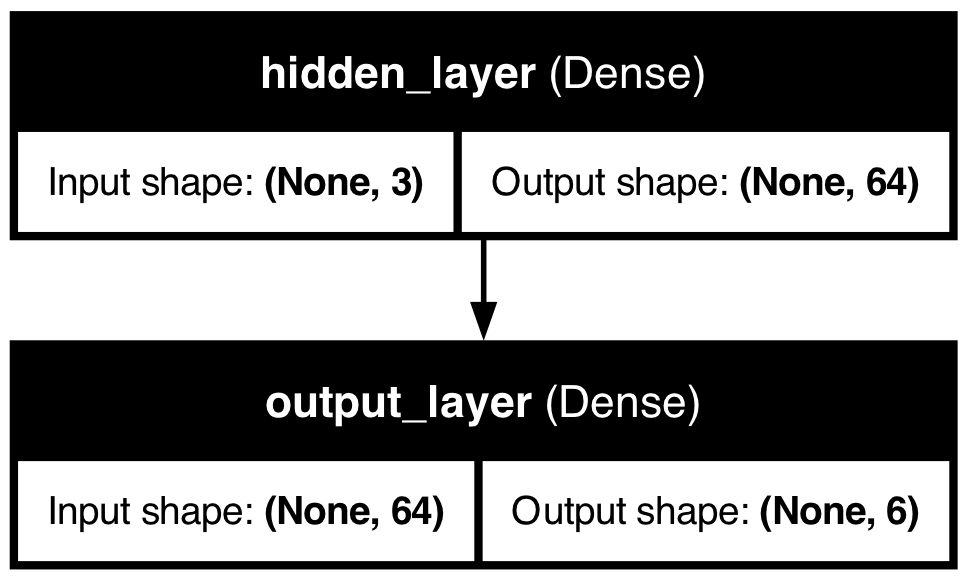

In [21]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file = "model1.png", show_shapes = True, show_layer_names = True)

In [22]:
# training
epochs = 100
batch_size = 256
history = model.fit(x_train_scaled, y_train, epochs = epochs, batch_size = batch_size, validation_split = 0.1, verbose = 1)

Epoch 1/100


2025-05-07 22:31:49.888567: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1358 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00

In [23]:
loss, accuracy = model.evaluate(x_train_scaled, y_train)
loss, accuracy

451/451 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0000e+00 - loss: nan


(nan, 0.0)